In [1]:
import os
import numpy as np
import pandas as pd
import itertools as itt
import matplotlib.pyplot as plt

In [2]:
# Moving to test/validation evaluations
os.chdir('/nemo/lab/froehlichf/home/users/fabring/DeepMechanisticModels/evaluations/EGFR_MAPK/dream_cytof/training/test/')

In [3]:
## SIMPLY COPYING OVER training_configuration.py
# ORTHOGONAL REGULARISATION STRATEGIES: L1 vs L2
ORTH_REG_STRATEGIES = (
    # "L1",
    "L2",  # restricting to L2 only post stat tests
)

# Define common linear scan range
LINEAR_SCAN_RANGE = (0, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10)
LINEAR_SCAN_CENTRAL = 1e5
# Define linear scan for LATENT_DIMS
LATENT_DIMS_SCAN_RANGE = (1, 2, 3, 4, 6, 8, 10)
LATENT_DIMS_CENTRAL = 4

# ALPHAS: values for l1reg_inflate: l1 regularisation of layers that inflate from latent/bottleneck to kinetic params.
# From W&B, it seems that rmse_val.min is positively correlated with l1reg params
# i.e. the lower the regularisation, the lower the rmse -- this does not hold for transcriptomics.
# ALPHAS = (
#     0,  # tested
#     # 1e1,
#     # 5e1,
#     # 1e2, # tested
#     # 1e3,
#     # 1e4, # tested
#     1e6,  # reenable
#     1e8,
#     1e10,  # increasing values
# )
ALPHAS = {'range': LINEAR_SCAN_RANGE, 'central_value': LINEAR_SCAN_CENTRAL}

# BETAS: values for oreg_inflate: orthogonal regularisation for layers that inflate from bottleneck to kinetic params.
# From W&B, it seems like oreg params are negatively correlated with rmse_val.min, i.e. the higher the params,
# the lower the rmse_val.min
# BETAS = (
#     0,  # tested
#     1e2,  # reenable -- restricting to 1e2 only as it does not seem to have much of an impact!
#     # 1e4, # tested
#     # 1e6, # tested
#     # 1e7,
#     # 1e8,
#     )
BETAS = {'range': LINEAR_SCAN_RANGE, 'central_value': LINEAR_SCAN_CENTRAL}

# GAMMAS: values for l1reg_encode: l1 regularisation of encoder network (from inputs to bottleneck).
# GAMMAS = (
#     0,  # tested
#     # 1e1,
#     # 5e1,
#     # 1e2,  # tested
#     # 1e3,
#     # 1e4,  # tested
#     1e6,  # tested
#     1e8,
#     1e10,  # increasing values
# )
GAMMAS = {'range': LINEAR_SCAN_RANGE, 'central_value': LINEAR_SCAN_CENTRAL}

# DELTAS: values for oreg_encode: orthogonal regularisation of encoder network (from inputs to bottleneck)
# DELTAS = (
#     0,  # tested
#     # 1e2, # tested
#     # 1e4, # tested
#     1e6,  # tested
#     # 1e7,
#     1e8,
#     1e10,  # increasing values
# )
DELTAS = {'range': LINEAR_SCAN_RANGE, 'central_value': LINEAR_SCAN_CENTRAL}

# n_hidden: number of dimensions of bottleneck representation obtained using the encoder.
# From W&B, it does not seem to matter much, but it is slightly positively correlated with rmse_val.min - lower
# appears to be better? -- stat tests show the same.
# LATENT_DIMS = (
#     2,
#     # 3,
#     4,
#     6,
#     8,
#     # 10,
#     # 12
# )
LATENT_DIMS = {'range': LATENT_DIMS_SCAN_RANGE, 'central_value': LATENT_DIMS_CENTRAL}

CONTEXTS_FEATURES = (
    ("cytof_init", "all"),
    # ("cytof_init", "rfe"),
    # ("cytof_init", "lasso"),
    # ("cytof_init", "elastic"),
    # ("cytof_init", "sequential"),
    # ("cytof_dynamic", "all"),
    ("proteomics", "all"),
    # ("proteomics", "rfe"),
    # ("proteomics", "lasso"),
    # ("proteomics", "elastic"),
    # ("proteomics", "sequential"),
    ("transcriptomics", "all"),
    # ("transcriptomics", "rfe"),
    # ("transcriptomics", "lasso"),
    # ("transcriptomics", "elastic"),
    # ("transcriptomics", "sequential"),
)
# NOT CURRENTLY IN USE, REPLACED BY CONTEXTS_FEATURES
# CONTEXTS = (
#     "proteomics",
#     "transcriptomics",
#     "cytof_init",
#     "cytof_dynamic",
# )
# FEATURES = (
#     "pca",
#     "all",
#     "rfe",
#     "lasso",
#     "elastic",
#     "sequential",
# )
PATHWAYS = ("EGFR_MAPK",)
DATASETS = ("dream_cytof",)
# DATASETS = {
#    'synthetic_16_0.2_0.0',
#     'synthetic_32_0.2_0.0',
#     'synthetic_64_0.2_0.0',
#     'synthetic_128_0.2_0.0',
# }
SPLITS = {
    "0_5",
    # '1_5',
    # '2_5',
    # '3_5',
    # '4_5'
}
PRETRAIN = {
    "True",
}

NUM_STARTS = 10
RETURN_STAT_TESTS = False

In [4]:
class SafeDict(dict):
    def __missing__(self, key):
        return '{' + key + '}'
    
defaults = {
    x: f"{{{x}}}"
    for x in [
        "context",
        "samples",
        "n_hidden",
        "job",  # need job field in EVALUATION_TRAINING
        "features",
        "orth_reg_strategy",
        "l1reg_inflate",
        "oreg_inflate",
        "l1reg_encode",
        "oreg_encode",
    ]
}
tpl_evaluation_file = "__".join(defaults.values())
EVALUATION_TRAINING = str(
    (tpl_evaluation_file + ".csv")
)

In [5]:
def generate_hyperparam_scans():
    STARTS = [str(i) for i in range(NUM_STARTS)]

    if (
            isinstance(ALPHAS, tuple)
            and isinstance(BETAS, tuple)
            and isinstance(GAMMAS, tuple)
            and isinstance(DELTAS, tuple)
            and isinstance(LATENT_DIMS, tuple)
    ):
        mode = "product_grid"
    elif (
            isinstance(ALPHAS, dict)
            and isinstance(BETAS, dict)
            and isinstance(GAMMAS, dict)
            and isinstance(DELTAS, dict)
            and isinstance(LATENT_DIMS, dict)
    ):
        mode = "linear_scan"
    else:
        raise TypeError("Inconsistent typing for hyperparameter scans!")


    hyperparams = {
        "l1reg_inflate": ALPHAS,
        "oreg_inflate": BETAS,
        "l1reg_encode": GAMMAS,
        "oreg_encode": DELTAS,
        "n_hidden": LATENT_DIMS,
    }

    if mode == 'linear_scan':
        central_values = {
            hyperparam: hyperparams[hyperparam]['central_value']
            for hyperparam in hyperparams.keys()
        }
        hyperparam_configurations = [
            {
                **central_values,
                hyperparam: hp_value,
                "orth_reg_strategy": orth_reg_strategy,
                "context": context,
                "features": features,
                "samples": split,
                "pretrain": pretrain,
                "job": job,
            }
            for hyperparam, details in hyperparams.items()
            for hp_value in details['range']
            for (context, features), orth_reg_strategy, split, pretrain, job in itt.product(
                CONTEXTS_FEATURES,
                ORTH_REG_STRATEGIES,
                SPLITS,
                PRETRAIN,
                STARTS
            )
        ]
    elif mode == 'product_grid':
        hyperparam_configurations = [
            {
                "l1reg_inflate": alpha,
                "oreg_inflate": beta,
                "l1reg_encode": gamma,
                "oreg_encode": delta,
                "n_hidden": latent_dim,
                "orth_reg_strategy": orth_reg_strategy,
                "context": context,
                "features": features,
                "samples": split,
                "pretrain": pretrain,
                "job": job,
            }
            for alpha, beta, gamma, delta, latent_dim, orth_reg_strategy, (context, features), split, pretrain, job in itt.product(
                ALPHAS,
                BETAS,
                GAMMAS,
                DELTAS,
                LATENT_DIMS,
                ORTH_REG_STRATEGIES,
                CONTEXTS_FEATURES,
                SPLITS,
                PRETRAIN,
                STARTS
            )
        ]

    training_evaluations = [
        EVALUATION_TRAINING.format_map(SafeDict(**hyperparam_configuration))
        for hyperparam_configuration in hyperparam_configurations
    ]
    return training_evaluations
# print(training_evaluations)

In [6]:
configurations = generate_hyperparam_scans()

In [7]:
configurations_context = {
    context: [
        configuration for configuration in configurations 
        if configuration.startswith(context)
    ]
    for context, _ in CONTEXTS_FEATURES
}

In [8]:
def generate_linear_scan(chosen_context, chosen_hyperparam):
    STARTS = [str(i) for i in range(NUM_STARTS)]

    hyperparams = {
        "l1reg_inflate": ALPHAS,
        "oreg_inflate": BETAS,
        "l1reg_encode": GAMMAS,
        "oreg_encode": DELTAS,
        "n_hidden": LATENT_DIMS,
    }

    central_values = {
        hyperparam: hyperparams[hyperparam]['central_value']
        for hyperparam in hyperparams.keys()
    }
    
    hyperparam_configurations = [
        {
            **central_values,
            chosen_hyperparam: hp_value,
            "orth_reg_strategy": orth_reg_strategy,
            "context": chosen_context,
            "features": features,
            "samples": split,
            "pretrain": pretrain,
            "job": job,
        }
        for hp_value in hyperparams[chosen_hyperparam]['range']
        for (_, features), orth_reg_strategy, split, pretrain, job in itt.product(
            CONTEXTS_FEATURES,
            ORTH_REG_STRATEGIES,
            SPLITS,
            PRETRAIN,
            STARTS
        )
    ]

    training_evaluations = [
        EVALUATION_TRAINING.format_map(SafeDict(**hyperparam_configuration))
        for hyperparam_configuration in hyperparam_configurations
    ]
    return training_evaluations
# print(training_evaluations)

In [9]:
def select_from_linear_scan(chosen_context, chosen_hyperparam, chosen_hp_value):
    STARTS = [str(i) for i in range(NUM_STARTS)]

    hyperparams = {
        "l1reg_inflate": ALPHAS,
        "oreg_inflate": BETAS,
        "l1reg_encode": GAMMAS,
        "oreg_encode": DELTAS,
        "n_hidden": LATENT_DIMS,
    }

    central_values = {
        hyperparam: hyperparams[hyperparam]['central_value']
        for hyperparam in hyperparams.keys()
    }
    
    hyperparam_configurations = [
        {
            **central_values,
            chosen_hyperparam: chosen_hp_value,
            "orth_reg_strategy": orth_reg_strategy,
            "context": chosen_context,
            "features": features,
            "samples": split,
            "pretrain": pretrain,
            "job": job,
        }
        for (_, features), orth_reg_strategy, split, pretrain, job in itt.product(
            CONTEXTS_FEATURES,
            ORTH_REG_STRATEGIES,
            SPLITS,
            PRETRAIN,
            STARTS
        )
    ]

    training_evaluations = [
        EVALUATION_TRAINING.format_map(SafeDict(**hyperparam_configuration))
        for hyperparam_configuration in hyperparam_configurations
    ]
    return training_evaluations


# Effect of n_hidden

In [10]:
def get_rmse(df): 
    return np.sqrt(np.square(df["res"]).mean())

In [13]:
rmse_n_hidden = {context: {} for context, _ in CONTEXTS_FEATURES}
for (context, _), n_hidden in itt.product(CONTEXTS_FEATURES, LATENT_DIMS['range']):
    # Extract configurations for the given context and n_hidden
    configurations = select_from_linear_scan(
        chosen_context=context,
        chosen_hyperparam='n_hidden', 
        chosen_hp_value=n_hidden
    )

    # Compute RMSEs for all relevant configurations
    job_rmses = [
        get_rmse(pd.read_csv(configuration))
        for configuration in configurations
    ]

    # Store the result in the dictionary under the appropriate key
    rmse_n_hidden[context][n_hidden] = {
        'job_rmses': np.array(job_rmses), 
        'mean_rmse': np.mean(job_rmses), 
        'std_rmse': np.std(job_rmses, ddof=1)
    }

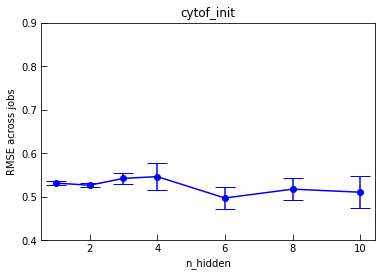

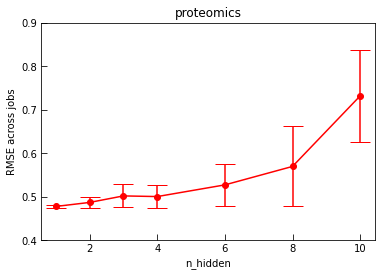

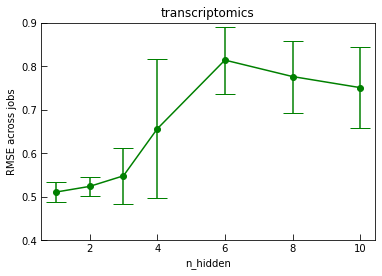

In [14]:
colours = {
    "cytof_init": 'blue', 
    "proteomics": 'red', 
    "transcriptomics": 'green'
}

for context, _ in CONTEXTS_FEATURES: 
    plt.figure(figsize=(6, 4))
    plt.errorbar(
        LATENT_DIMS['range'], 
        np.array(
        [
            rmse_n_hidden[context][n_hidden]['mean_rmse']
            for n_hidden in LATENT_DIMS['range']
        ]
        ), 
        np.array(
        [
            rmse_n_hidden[context][n_hidden]['std_rmse']
            for n_hidden in LATENT_DIMS['range']
        ]
        ), 
        capsize=10,
        marker='o',
        ms=6,
        color=colours[context]
    )
    plt.xlabel('n_hidden')
    plt.ylabel('RMSE across jobs')
    plt.ylim([0.4, 0.9])
    plt.gca().tick_params(direction='in', length=6)
    plt.title(context)

# Effect of l1reg_inflate

In [15]:
rmse_alpha = {context: {} for context, _ in CONTEXTS_FEATURES}
for (context, _), alpha in itt.product(CONTEXTS_FEATURES, ALPHAS['range']):
    # Extract configurations for the given context and n_hidden
    configurations = select_from_linear_scan(
        chosen_context=context,
        chosen_hyperparam='l1reg_inflate', 
        chosen_hp_value=alpha
    )

    # Compute RMSEs for all relevant configurations
    job_rmses = [
        get_rmse(pd.read_csv(configuration))
        for configuration in configurations
    ]

    # Store the result in the dictionary under the appropriate key
    rmse_alpha[context][alpha] = {
        'job_rmses': np.array(job_rmses), 
        'mean_rmse': np.mean(job_rmses), 
        'std_rmse': np.std(job_rmses, ddof=1)
    }

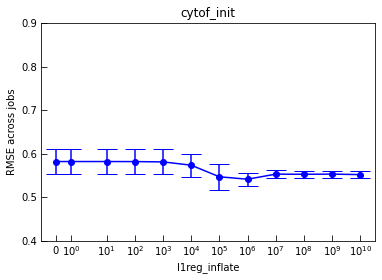

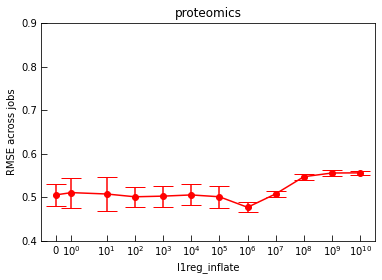

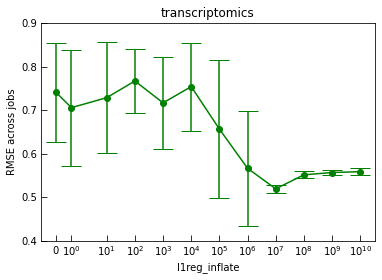

In [16]:
colours = {
    "cytof_init": 'blue', 
    "proteomics": 'red', 
    "transcriptomics": 'green'
}

for context, _ in CONTEXTS_FEATURES: 
    plt.figure(figsize=(6, 4))
    plt.errorbar(
        ALPHAS['range'], 
        np.array(
        [
            rmse_alpha[context][n_hidden]['mean_rmse']
            for n_hidden in ALPHAS['range']
        ]
        ), 
        np.array(
        [
            rmse_alpha[context][n_hidden]['std_rmse']
            for n_hidden in ALPHAS['range']
        ]
        ), 
        capsize=10,
        marker='o',
        ms=6,
        color=colours[context]
    )
    plt.xlabel('l1reg_inflate')
    plt.ylabel('RMSE across jobs')
    plt.xscale('symlog')
    plt.ylim([0.4, 0.9])
    plt.gca().tick_params(direction='in', length=6)
    plt.title(context)

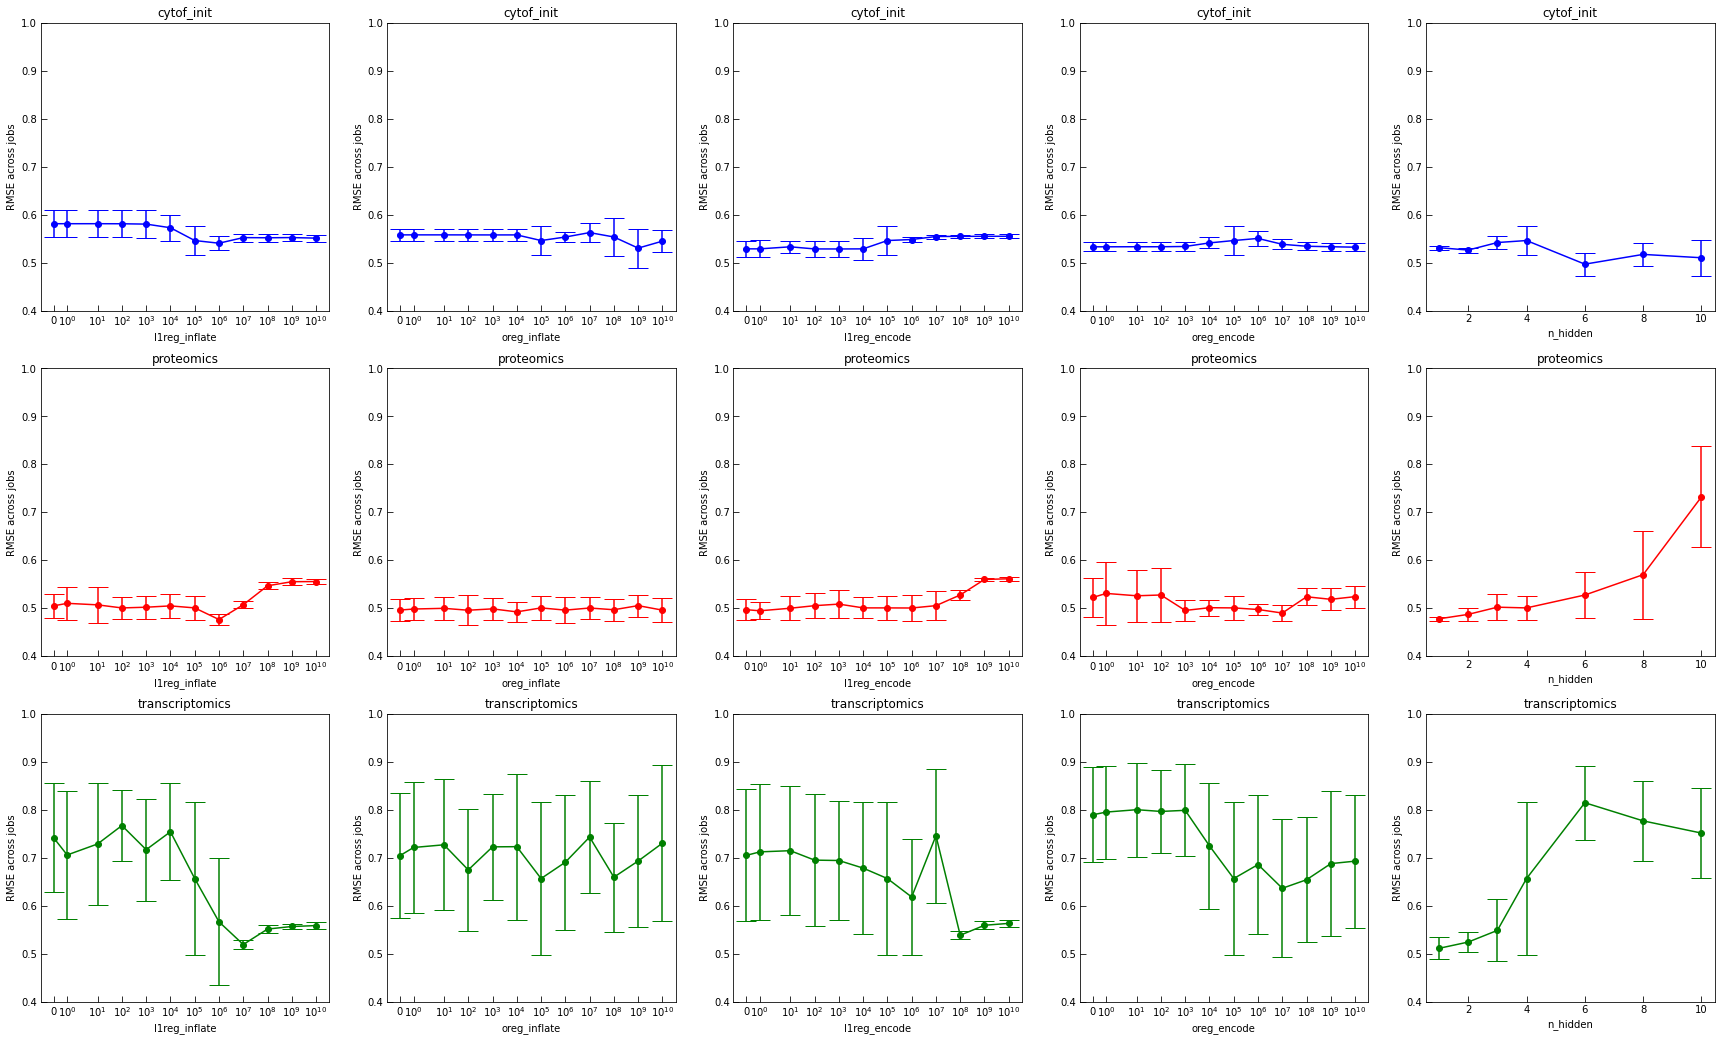

In [12]:
hyperparams = {
        "l1reg_inflate": ALPHAS,
        "oreg_inflate": BETAS,
        "l1reg_encode": GAMMAS,
        "oreg_encode": DELTAS,
        "n_hidden": LATENT_DIMS,
    }
colours = {
    "cytof_init": 'blue', 
    "proteomics": 'red', 
    "transcriptomics": 'green'
}

plt.subplots(3, len(hyperparams.keys()), figsize=(30, 18))
for ind, hyperparameter in enumerate(hyperparams.keys()): 
    rmse_dict = {context: {} for context, _ in CONTEXTS_FEATURES}
    for context_ind, (context, _) in enumerate(CONTEXTS_FEATURES):
        for hp_value in hyperparams[hyperparameter]['range']:
        # Extract configurations for the given context and hyperparameter
            configurations = select_from_linear_scan(
                chosen_context=context,
                chosen_hyperparam=hyperparameter, 
                chosen_hp_value=hp_value
            )

            # Compute RMSEs for all relevant configurations
            job_rmses = [
                get_rmse(pd.read_csv(configuration))
                for configuration in configurations
            ]

            # Store the result in the dictionary under the appropriate key
            rmse_dict[context][hp_value] = {
    #             'job_rmses': np.array(job_rmses), 
                'mean_rmse': np.mean(job_rmses), 
                'std_rmse': np.std(job_rmses, ddof=1)
            }
        
        plt.subplot(3, len(hyperparams.keys()), ind+1+context_ind*len(hyperparams.keys()))
        plt.errorbar(
            hyperparams[hyperparameter]['range'], 
            np.array(
            [
                rmse_dict[context][hp_value]['mean_rmse']
                for hp_value in hyperparams[hyperparameter]['range']
            ]
            ), 
            np.array(
            [
                rmse_dict[context][hp_value]['std_rmse']
                for hp_value in hyperparams[hyperparameter]['range']
            ]
            ), 
            capsize=10,
            marker='o',
            ms=6,
            color=colours[context]
        )
        plt.xlabel(hyperparameter)
        if not hyperparameter == 'n_hidden': 
            plt.xscale('symlog')
        plt.ylabel('RMSE across jobs')
        plt.ylim([0.4, 1.0])
        plt.gca().tick_params(direction='in', length=6)
        plt.title(context)
plt.savefig('/nemo/lab/froehlichf/home/users/fabring/DeepMechanisticModels/linear_scans_2024_04_12_5e-4_minimprovement.svg')
plt.savefig('/nemo/lab/froehlichf/home/users/fabring/DeepMechanisticModels/linear_scans_2024_04_12_5e-4_minimprovement.pdf')